### FORWARD FEATURE SELECTION - PROTON THERAPY ###

In [262]:
# importing all libraries:

import random as rd
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns

In [263]:
# READING INITIAL DATASET
proton_dataset = pd.read_csv("Workload_UFHPTI2.csv")

# Dropping non-numeric column (dates)
df_proton = proton_dataset.drop(columns=["Date"])

df_proton.head()

,Sessions,TxHours_subDelay,AvgFieldsPerPt,AvgLayersPerPt,AvgNumSpotsPerPt,Anesthesia,CSI,CSI or Anesthesia,BID,TID,Pediatric,HN,Prostate,Brain,Breast,Bone,Thorax,Abdomen,CNS,Pelvis,Other,Spine,Month,Quarter,Year,Pacemaker
0,17,8.532933,2.529412,19.019608,2347.009804,0,0,0,0,0,3,1,6,3,1,0,0,0,5,1,0,0,1,1,2020,0
1,21,10.699600,2.619048,20.785714,2434.095238,0,0,0,0,0,5,3,5,4,1,1,0,0,6,1,0,0,1,1,2020,0
2,21,9.649600,2.571429,20.357143,2280.626984,0,0,0,0,0,5,3,5,4,1,1,0,0,6,1,0,0,1,1,2020,0
3,18,8.549600,2.555556,20.333333,2382.629630,0,0,0,0,0,5,2,5,3,1,1,0,0,5,1,0,0,1,1,2020,0
4,17,8.166267,2.470588,20.568627,2323.147059,0,0,0,0,0,4,2,5,3,1,1,0,0,4,1,0,0,1,1,2020,0


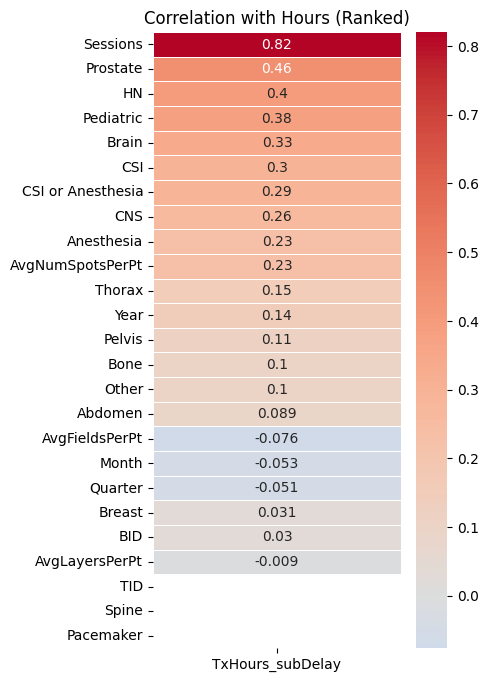

In [264]:
# Correlation of all variables with 'hours'
corr_matrix = df_proton.corr()
hours_corr = df_proton.corr()[["TxHours_subDelay"]]

# Remove self-correlation
hours_corr = hours_corr.drop("TxHours_subDelay")

# Sort by absolute correlation (strongest first)
hours_corr_sorted = hours_corr.reindex(
    hours_corr["TxHours_subDelay"].abs().sort_values(ascending=False).index
)

plt.figure(figsize=(4, 8))
sns.heatmap(
    hours_corr_sorted,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation with Hours (Ranked)")
plt.show()


In [265]:
# Outcome + predictors you want counts for

count_cols = [
    "Prostate", "HN", "Pediatric", "Brain", "CSI", "CNS", "Anesthesia", "Thorax", "Pelvis",
    "Bone", "Other", "Abdomen", "Breast", "Spine"]

df_model = df_proton[["TxHours_subDelay", "Sessions"] + count_cols].copy()

# Create pct_ columns for everything in count_cols
pct_cols = [f"pct_{c}" for c in count_cols]
df_model[pct_cols] = df_model[count_cols].div(df_model["Sessions"], axis=0)

df_model.head(5)

,TxHours_subDelay,Sessions,Prostate,HN,Pediatric,Brain,CSI,CNS,Anesthesia,Thorax,Pelvis,Bone,Other,Abdomen,Breast,Spine,pct_Prostate,pct_HN,pct_Pediatric,pct_Brain,pct_CSI,pct_CNS,pct_Anesthesia,pct_Thorax,pct_Pelvis,pct_Bone,pct_Other,pct_Abdomen,pct_Breast,pct_Spine
0,8.532933,17,6,1,3,3,0,5,0,0,1,0,0,0,1,0,0.352941,0.058824,0.176471,0.176471,0.0,0.294118,0.0,0.0,0.058824,0.000000,0.0,0.0,0.058824,0.0
1,10.699600,21,5,3,5,4,0,6,0,0,1,1,0,0,1,0,0.238095,0.142857,0.238095,0.190476,0.0,0.285714,0.0,0.0,0.047619,0.047619,0.0,0.0,0.047619,0.0
2,9.649600,21,5,3,5,4,0,6,0,0,1,1,0,0,1,0,0.238095,0.142857,0.238095,0.190476,0.0,0.285714,0.0,0.0,0.047619,0.047619,0.0,0.0,0.047619,0.0
3,8.549600,18,5,2,5,3,0,5,0,0,1,1,0,0,1,0,0.277778,0.111111,0.277778,0.166667,0.0,0.277778,0.0,0.0,0.055556,0.055556,0.0,0.0,0.055556,0.0
4,8.166267,17,5,2,4,3,0,4,0,0,1,1,0,0,1,0,0.294118,0.117647,0.235294,0.176471,0.0,0.235294,0.0,0.0,0.058824,0.058824,0.0,0.0,0.058824,0.0


### ONLY TYPES OF CASES ###

\begin{align}
\text{Hours} &= \beta_0 
+ \beta_1 (HN)
+ \beta_2 (CNS) \\
&\quad + \beta_3 (Pediatric) 
+ \beta_4 (Anesthesia)
+ \beta_5 (Brain) \\
&\quad + \beta_6 (Abdomen)
+ \beta_7 (CSI)
+ \beta_8 (Thorax) \\
&\quad + \beta_{9} (Pelvis) 
+ \beta_{10} (BID)
+ \beta_{11} (Bone) \\
&\quad + \beta_{12} (Breast)
+ \beta_{13} (Prostate)
+ \beta_{14} (Other)
+ \varepsilon
\end{align}

In [266]:
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# 1. Define predictors and outcome

predictor_cols = [
    "Prostate", "HN", "Pediatric", "Brain", "CSI", "CNS", "Anesthesia", "Thorax", "Pelvis",
    "Bone", "Other", "Abdomen", "Breast", "Spine"]

X = df_model[predictor_cols]
y = df_model["TxHours_subDelay"]

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 2. Forward stepwise selection with CV

def forward_stepwise_cv(X, y, cv=5, scoring='neg_root_mean_squared_error'):
    remaining_features = list(X.columns)
    selected_features = []
    results = []

    kf = KFold(n_splits=cv, shuffle=True, random_state=42)

    for step in range(1, len(X.columns) + 1):
        step_scores = []

        for candidate in remaining_features:
            trial_features = selected_features + [candidate]
            model = LinearRegression()

            cv_scores = cross_val_score(
                model,
                X[trial_features],
                y,
                cv=kf,
                scoring=scoring
            )

            mean_score = np.mean(cv_scores)

            cv_r2 = cross_val_score(
                model,
                X[trial_features],
                y,
                cv=kf,
                scoring='r2'
            ).mean()

            step_scores.append({
                "step": step,
                "candidate_added": candidate,
                "features": trial_features.copy(),
                "cv_score": mean_score,
                "cv_rmse": -mean_score,
                "cv_r2": cv_r2
            })

        step_df = pd.DataFrame(step_scores)
        best_row = step_df.loc[step_df["cv_score"].idxmax()]

        best_feature = best_row["candidate_added"]
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)

        results.append({
            "n_features": step,
            "added_feature": best_feature,
            "selected_features": selected_features.copy(),
            "cv_rmse": best_row["cv_rmse"],
            "cv_r2": best_row["cv_r2"]
        })

    results_df = pd.DataFrame(results)
    return results_df, selected_features


In [267]:
# Run forward stepwise on training data
results_df, ordered_features = forward_stepwise_cv(X_train, y_train, cv=5)

print("Ordered features:")
print(ordered_features)

Ordered features:
['Prostate', 'HN', 'Pediatric', 'CNS', 'Brain', 'Anesthesia', 'Pelvis', 'Abdomen', 'Thorax', 'Bone', 'Other', 'CSI', 'Breast', 'Spine']


In [268]:
# FINAL FIGURE (FORWARD FEATURE SELECTION)

# Build cumulative feature list
selected_features = []
current = []

for f in results_df["added_feature"]:
    current = current + [f]
    selected_features.append(current.copy())

# Create clean dataframe
clean_df = pd.DataFrame({
    "n Features": results_df["n_features"],
    "Selected Features": selected_features,
    "CV RMSE": results_df["cv_rmse"],
    "CV R2": results_df["cv_r2"]
})

# Display settings
pd.set_option('display.max_colwidth', None)

clean_df

,n Features,Selected Features,CV RMSE,CV R2
0,1,[Prostate],1.818540,0.212776
1,2,"[Prostate, HN]",1.561807,0.418797
2,3,"[Prostate, HN, Pediatric]",1.230477,0.637791
3,4,"[Prostate, HN, Pediatric, CNS]",1.116346,0.702144
4,5,"[Prostate, HN, Pediatric, CNS, Brain]",1.055375,0.733866
5,6,"[Prostate, HN, Pediatric, CNS, Brain, Anesthesia]",1.018191,0.752873
6,7,"[Prostate, HN, Pediatric, CNS, Brain, Anesthesia, Pelvis]",0.981389,0.770283
7,8,"[Prostate, HN, Pediatric, CNS, Brain, Anesthesia, Pelvis, Abdomen]",0.952366,0.783740
8,9,"[Prostate, HN, Pediatric, CNS, Brain, Anesthesia, Pelvis, Abdomen, Thorax]",0.929315,0.794188
9,10,"[Prostate, HN, Pediatric, CNS, Brain, Anesthesia, Pelvis, Abdomen, Thorax, Bone]",0.904327,0.805515


In [269]:
# 3. Compute Adjusted R², AIC, BIC for each model size

metrics_list = []

for k in range(1, len(ordered_features) + 1):
    features_k = ordered_features[:k]

    X_train_k = sm.add_constant(X_train[features_k])
    model_k = sm.OLS(y_train, X_train_k).fit()

    metrics_list.append({
        "n Features": k,
        "Features": features_k,
        "Adjusted R2": model_k.rsquared_adj,
        "AIC": model_k.aic,
        "BIC": model_k.bic
    })

model_metrics = pd.DataFrame(metrics_list)

df_cases = model_metrics.drop(columns="Features")
df_cases.head(16)

,n Features,Adjusted R2,AIC,BIC
0,1,0.222060,3516.396124,3525.937703
1,2,0.426407,3251.668762,3265.981131
2,3,0.643433,2838.118260,2857.201418
3,4,0.705279,2673.002906,2696.856854
4,5,0.737083,2574.421696,2603.046433
5,6,0.757385,2505.339979,2538.735505
6,7,0.775480,2438.739218,2476.905533
7,8,0.788888,2386.036021,2428.973126
8,9,0.800198,2339.012245,2386.720139
9,10,0.810826,2292.338211,2344.816894


In [270]:
# 4. Find best model sizes by each metric

best_adj_r2_row = model_metrics.loc[model_metrics["Adjusted R2"].idxmax()]
best_aic_row = model_metrics.loc[model_metrics["AIC"].idxmin()]
best_bic_row = model_metrics.loc[model_metrics["BIC"].idxmin()]

print("\nBest by Adjusted R²:")
print(best_adj_r2_row)

print("\nBest by AIC:")
print(best_aic_row)

print("\nBest by BIC:")
print(best_bic_row)

print("")

# Row with lowest CV RMSE
best_model_info = results_df.loc[results_df["cv_rmse"].idxmin()]

optimal_k = best_model_info["n_features"]
best_features = best_model_info["selected_features"]

print("Best by CV RMSE:")
print("Optimal number of predictors:", optimal_k)
print("Best predictors:", best_features)
print("Best CV RMSE:", best_model_info["cv_rmse"])
print("Best CV R^2:", best_model_info["cv_r2"])


Best by Adjusted R²:
n Features                                                                                                       13
Features       [Prostate, HN, Pediatric, CNS, Brain, Anesthesia, Pelvis, Abdomen, Thorax, Bone, Other, CSI, Breast]
Adjusted R2                                                                                                0.820592
AIC                                                                                                     2249.070985
BIC                                                                                                     2315.862037
Name: 12, dtype: object

Best by AIC:
n Features                                                                                                       13
Features       [Prostate, HN, Pediatric, CNS, Brain, Anesthesia, Pelvis, Abdomen, Thorax, Bone, Other, CSI, Breast]
Adjusted R2                                                                                                0.820592
AIC         

In [271]:
# 5. Choose one final model

best_features = best_adj_r2_row["Features"]

X_train_final = sm.add_constant(X_train[best_features])
X_test_final = sm.add_constant(X_test[best_features])

final_model = sm.OLS(y_train, X_train_final).fit()
print(final_model.summary())


                            OLS Regression Results                            
Dep. Variable:       TxHours_subDelay   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     307.5
Date:                Sun, 12 Apr 2026   Prob (F-statistic):          4.68e-312
Time:                        22:15:43   Log-Likelihood:                -1110.5
No. Observations:                 872   AIC:                             2249.
Df Residuals:                     858   BIC:                             2316.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9999      0.163     18.446      0.0

In [272]:
# Predictions on test set
y_pred = final_model.predict(X_test_final)

print("\nTest Metrics")
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))


Test Metrics
R²: 0.8509534167629904
RMSE: 0.8357017278545377
MAE: 0.6583880917892612


In [273]:
# Fit statsmodels OLS on training set with the best predictors
X_train_best_sm = sm.add_constant(X_train[best_features])
X_test_best_sm = sm.add_constant(X_test[best_features])

final_model = sm.OLS(y_train, X_train_best_sm).fit()
print(final_model.summary())

# Predictions on test set
y_pred = final_model.predict(X_test_best_sm)

# Test metrics
test_r2 = r2_score(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)

print("\nFinal Test Metrics")
print("Test R^2:", test_r2)
print("Test MSE:", test_mse)
print("Test MAE:", test_mae)

                            OLS Regression Results                            
Dep. Variable:       TxHours_subDelay   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     307.5
Date:                Sun, 12 Apr 2026   Prob (F-statistic):          4.68e-312
Time:                        22:15:43   Log-Likelihood:                -1110.5
No. Observations:                 872   AIC:                             2249.
Df Residuals:                     858   BIC:                             2316.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9999      0.163     18.446      0.0

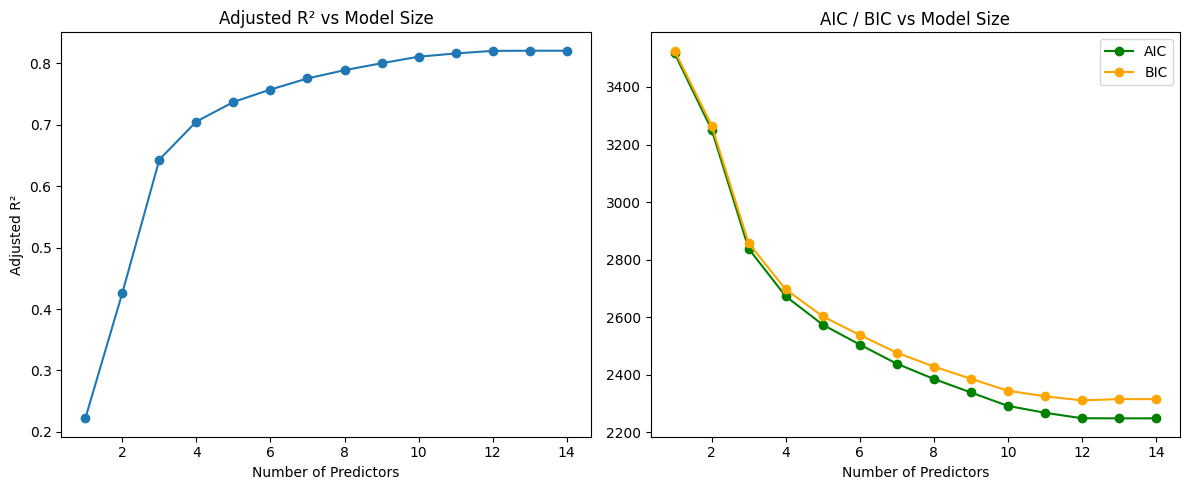

In [274]:
plt.figure(figsize=(12,5))

# Adjusted R2
plt.subplot(1,2,1)
plt.plot(model_metrics["n Features"], model_metrics["Adjusted R2"], marker="o")
plt.xlabel("Number of Predictors")
plt.ylabel("Adjusted R²")
plt.title("Adjusted R² vs Model Size")

# AIC/BIC
plt.subplot(1,2,2)
plt.plot(model_metrics["n Features"], model_metrics["AIC"], marker="o", label="AIC", color="green")
plt.plot(model_metrics["n Features"], model_metrics["BIC"], marker="o", label="BIC", color="orange")
plt.xlabel("Number of Predictors")
plt.title("AIC / BIC vs Model Size")
plt.legend()

plt.tight_layout()
plt.show()

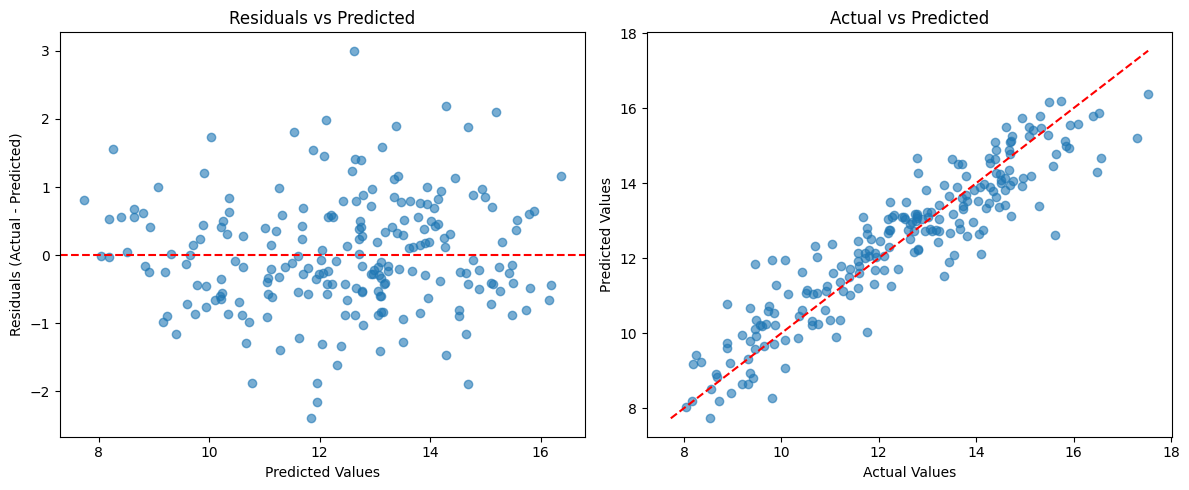

In [275]:
import matplotlib.pyplot as plt
import numpy as np

# Residuals
residuals = y_test - y_pred

# Create side-by-side subplots
plt.figure(figsize=(12,5))

# --- Plot 1: Residuals vs Predicted ---
plt.subplot(1,2,1)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--", color="Red")  # horizontal line at 0

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predicted")

# --- Plot 2: Actual vs Predicted ---
plt.subplot(1,2,2)
plt.scatter(y_test, y_pred, alpha=0.6)

# 45-degree reference line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="Red")


plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.tight_layout()
plt.show()

### SESSIONS AND PERCENTAGES ###

\begin{align}
\text{Hours} &= \beta_0 
+ \beta_1 (\text{Sessions}) 
+ \beta_2 (\%\text{HN})
+ \beta_3 (\%\text{CNS})
+ \beta_4 (\%\text{Pediatric}) 
+ \beta_5 (\%\text{Anesthesia})
+ \beta_6 (\%\text{Brain}) \\
&\quad + \beta_7 (\%\text{Abdomen})
+ \beta_8 (\%\text{CSI})
+ \beta_9 (\%\text{Thorax})
+ \beta_{10} (\%\text{Pelvis}) 
+ \beta_{11} (\%\text{BID})
+ \beta_{12} (\%\text{Bone}) \\
&\quad + \beta_{13} (\%\text{Breast})
+ \beta_{14} (\%\text{Prostate})
+ \beta_{15} (\%\text{Other})
+ \varepsilon
\end{align}

In [276]:
# Define Predictors 
predictor_cols = [
    "Sessions", "pct_Prostate", "pct_HN", "pct_Pediatric", "pct_Brain", "pct_CSI", "pct_CNS",
    "pct_Anesthesia", "pct_Thorax", "pct_Pelvis", "pct_Bone", "pct_Other", "pct_Abdomen", "pct_Breast", "pct_Spine"]

X = df_model[predictor_cols]
y = df_model["TxHours_subDelay"]

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 2. Forward stepwise selection with CV

def forward_stepwise_cv(X, y, cv=5, scoring='neg_root_mean_squared_error'):
    remaining_features = list(X.columns)
    selected_features = []
    results = []

    kf = KFold(n_splits=cv, shuffle=True, random_state=42)

    for step in range(1, len(X.columns) + 1):
        step_scores = []

        for candidate in remaining_features:
            trial_features = selected_features + [candidate]
            model = LinearRegression()

            cv_scores = cross_val_score(
                model,
                X[trial_features],
                y,
                cv=kf,
                scoring=scoring
            )

            mean_score = np.mean(cv_scores)

            cv_r2 = cross_val_score(
                model,
                X[trial_features],
                y,
                cv=kf,
                scoring='r2'
            ).mean()

            step_scores.append({
                "step": step,
                "candidate_added": candidate,
                "features": trial_features.copy(),
                "cv_score": mean_score,
                "cv_rmse": -mean_score,
                "cv_r2": cv_r2
            })

        step_df = pd.DataFrame(step_scores)
        best_row = step_df.loc[step_df["cv_score"].idxmax()]

        best_feature = best_row["candidate_added"]
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)

        results.append({
            "n_features": step,
            "added_feature": best_feature,
            "selected_features": selected_features.copy(),
            "cv_rmse": best_row["cv_rmse"],
            "cv_r2": best_row["cv_r2"]
        })

    results_df = pd.DataFrame(results)
    return results_df, selected_features


In [277]:
# Run forward stepwise on training data
results_df, ordered_features = forward_stepwise_cv(X_train, y_train, cv=5)

print("Ordered features:")
print(ordered_features)

Ordered features:
['Sessions', 'pct_Prostate', 'pct_Anesthesia', 'pct_Brain', 'pct_CSI', 'pct_HN', 'pct_Other', 'pct_Pediatric', 'pct_Spine', 'pct_Thorax', 'pct_Breast', 'pct_CNS', 'pct_Abdomen', 'pct_Bone', 'pct_Pelvis']


In [278]:
# FINAL FIGURE (FORWARD FEATURE SELECTION)

# Build cumulative feature list
selected_features = []
current = []

for f in results_df["added_feature"]:
    current = current + [f]
    selected_features.append(current.copy())

# Create clean dataframe
clean_df = pd.DataFrame({
    "n Features": results_df["n_features"],
    "Selected Features": selected_features,
    "CV RMSE": results_df["cv_rmse"],
    "CV R2": results_df["cv_r2"]
})

# Display settings
pd.set_option('display.max_colwidth', None)

clean_df

,n Features,Selected Features,CV RMSE,CV R2
0,1,[Sessions],1.182269,0.664578
1,2,"[Sessions, pct_Prostate]",1.014950,0.753347
2,3,"[Sessions, pct_Prostate, pct_Anesthesia]",0.959659,0.779889
3,4,"[Sessions, pct_Prostate, pct_Anesthesia, pct_Brain]",0.911847,0.801845
4,5,"[Sessions, pct_Prostate, pct_Anesthesia, pct_Brain, pct_CSI]",0.898078,0.807793
5,6,"[Sessions, pct_Prostate, pct_Anesthesia, pct_Brain, pct_CSI, pct_HN]",0.892088,0.810424
6,7,"[Sessions, pct_Prostate, pct_Anesthesia, pct_Brain, pct_CSI, pct_HN, pct_Other]",0.885961,0.812943
7,8,"[Sessions, pct_Prostate, pct_Anesthesia, pct_Brain, pct_CSI, pct_HN, pct_Other, pct_Pediatric]",0.883219,0.814063
8,9,"[Sessions, pct_Prostate, pct_Anesthesia, pct_Brain, pct_CSI, pct_HN, pct_Other, pct_Pediatric, pct_Spine]",0.883219,0.814063
9,10,"[Sessions, pct_Prostate, pct_Anesthesia, pct_Brain, pct_CSI, pct_HN, pct_Other, pct_Pediatric, pct_Spine, pct_Thorax]",0.883265,0.814020


In [279]:
# 3. Compute Adjusted R², AIC, BIC for each model size

metrics_list = []

for k in range(1, len(ordered_features) + 1):
    features_k = ordered_features[:k]

    X_train_k = sm.add_constant(X_train[features_k])
    model_k = sm.OLS(y_train, X_train_k).fit()

    metrics_list.append({
        "n_features": k,
        "features": features_k,
        "Adj_R2": model_k.rsquared_adj,
        "AIC": model_k.aic,
        "BIC": model_k.bic
    })

model_metrics = pd.DataFrame(metrics_list)

In [280]:
score_values = model_metrics.drop(columns="features")
score_values.head(16)

,n_features,Adj_R2,AIC,BIC
0,1,0.671361,2765.002675,2774.544254
1,2,0.758205,2498.410318,2512.722686
2,3,0.785103,2396.570323,2415.653481
3,4,0.806782,2304.835760,2328.689707
4,5,0.812190,2281.073469,2309.698205
5,6,0.814816,2269.789010,2303.184536
6,7,0.817391,2258.571250,2296.737565
7,8,0.819179,2250.978548,2293.915653
8,9,0.819179,2250.978548,2293.915653
9,10,0.819453,2250.647186,2298.355080


In [281]:
# 4. Find best model sizes by each metric

best_adj_r2_row = model_metrics.loc[model_metrics["Adj_R2"].idxmax()]
best_aic_row = model_metrics.loc[model_metrics["AIC"].idxmin()]
best_bic_row = model_metrics.loc[model_metrics["BIC"].idxmin()]

print("\nBest by Adjusted R²:")
print(best_adj_r2_row)

print("\nBest by AIC:")
print(best_aic_row)

print("\nBest by BIC:")
print(best_bic_row)

print("")

# Row with lowest CV RMSE
best_model_info = results_df.loc[results_df["cv_rmse"].idxmin()]

optimal_k = best_model_info["n_features"]
best_features = best_model_info["selected_features"]

print("Best by CV RMSE:")
print("Optimal number of predictors:", optimal_k)
print("Best predictors:", best_features)
print("Best CV RMSE:", best_model_info["cv_rmse"])



Best by Adjusted R²:
n_features                                                                                                                                                                   14
features      [Sessions, pct_Prostate, pct_Anesthesia, pct_Brain, pct_CSI, pct_HN, pct_Other, pct_Pediatric, pct_Spine, pct_Thorax, pct_Breast, pct_CNS, pct_Abdomen, pct_Bone]
Adj_R2                                                                                                                                                                 0.819568
AIC                                                                                                                                                                  2254.03738
BIC                                                                                                                                                                 2320.828432
Name: 13, dtype: object

Best by AIC:
n_features                                                  

In [282]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [283]:
# 5. Choose one final model (R2)

best_features = best_adj_r2_row["features"]

X_train_final = sm.add_constant(X_train[best_features])
X_test_final = sm.add_constant(X_test[best_features])

final_model = sm.OLS(y_train, X_train_final).fit()
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:       TxHours_subDelay   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     305.3
Date:                Sun, 12 Apr 2026   Prob (F-statistic):          5.35e-311
Time:                        22:15:50   Log-Likelihood:                -1113.0
No. Observations:                 872   AIC:                             2254.
Df Residuals:                     858   BIC:                             2321.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              2.7044      0.748      3.

In [284]:
# Predictions on test set (R2)
y_pred = final_model.predict(X_test_final)

print("\nTest Metrics")
print("R²:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


Test Metrics
R²: 0.8580114561718609
MSE: 0.6653250584702712
MAE: 0.6152138558013823


In [285]:
# 5. Choose one final model (BIC and CV Error)

best_features_BIC = best_bic_row["features"]

X_train_final_BIC = sm.add_constant(X_train[best_features_BIC])
X_test_final_BIC = sm.add_constant(X_test[best_features_BIC])

final_model_BIC = sm.OLS(y_train, X_train_final_BIC).fit()
print(final_model_BIC.summary())

                            OLS Regression Results                            
Dep. Variable:       TxHours_subDelay   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     494.2
Date:                Sun, 12 Apr 2026   Prob (F-statistic):          4.46e-316
Time:                        22:15:50   Log-Likelihood:                -1116.5
No. Observations:                 872   AIC:                             2251.
Df Residuals:                     863   BIC:                             2294.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.9328      0.354     11.

In [286]:
# Predictions on test set (BIC)
y_pred_BIC = final_model_BIC.predict(X_test_final_BIC)

print("\nTest Metrics")
print("R²:", r2_score(y_test, y_pred_BIC))
print("MSE:", mean_squared_error(y_test, y_pred_BIC))
print("MAE:", mean_absolute_error(y_test, y_pred_BIC))


Test Metrics
R²: 0.8535135683673565
MSE: 0.6864011071840805
MAE: 0.621010127378316


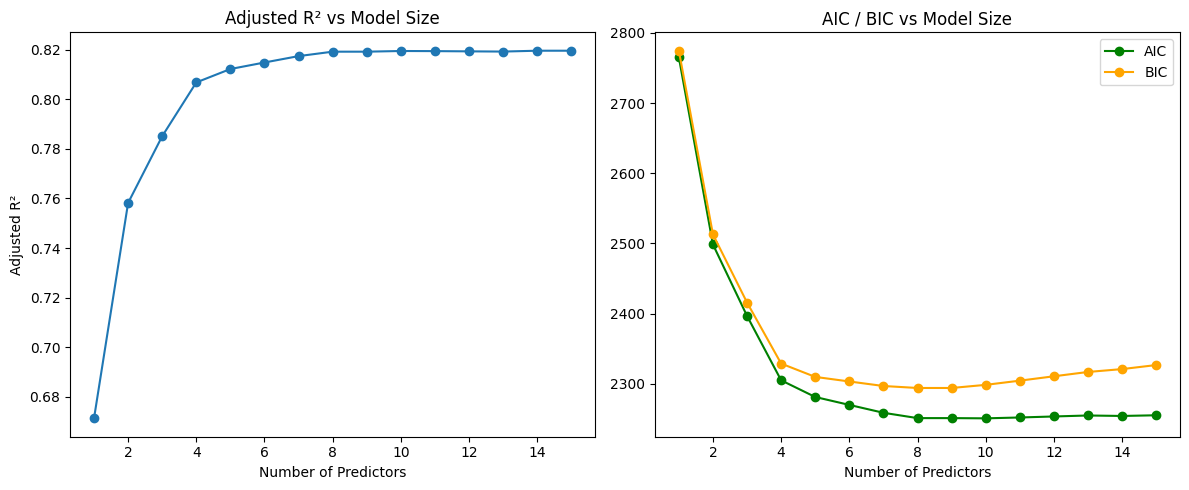

In [287]:
plt.figure(figsize=(12,5))

# Adjusted R2
plt.subplot(1,2,1)
plt.plot(model_metrics["n_features"], model_metrics["Adj_R2"], marker="o")
plt.xlabel("Number of Predictors")
plt.ylabel("Adjusted R²")
plt.title("Adjusted R² vs Model Size")

# AIC/BIC
plt.subplot(1,2,2)
plt.plot(model_metrics["n_features"], model_metrics["AIC"], marker="o", label="AIC", color="green")
plt.plot(model_metrics["n_features"], model_metrics["BIC"], marker="o", label="BIC", color="orange")
plt.xlabel("Number of Predictors")
plt.title("AIC / BIC vs Model Size")
plt.legend()

plt.tight_layout()
plt.show()

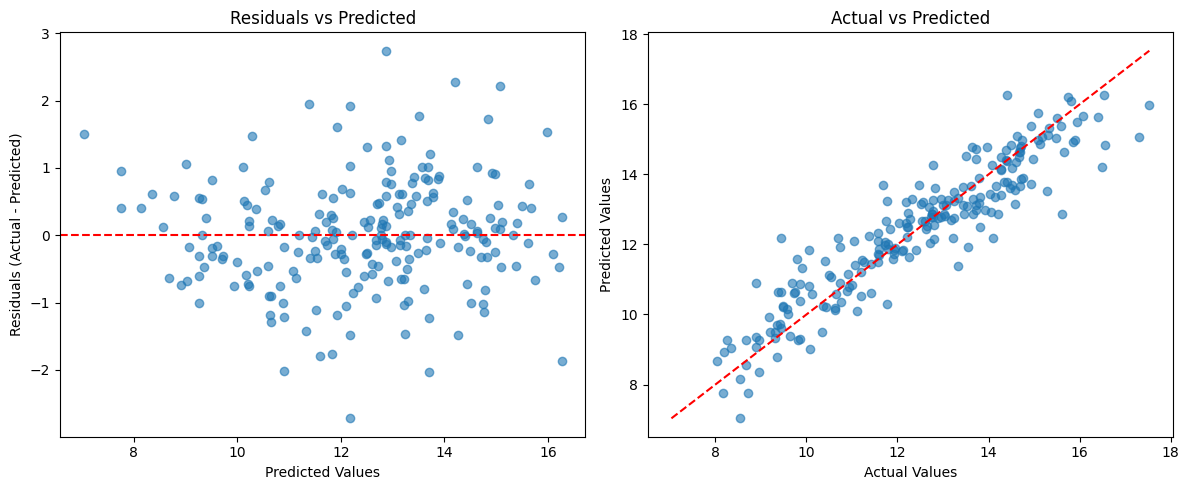

In [288]:
import matplotlib.pyplot as plt
import numpy as np

# Residuals
residuals = y_test - y_pred

# Create side-by-side subplots
plt.figure(figsize=(12,5))

# --- Plot 1: Residuals vs Predicted ---
plt.subplot(1,2,1)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--", color="Red")  # horizontal line at 0

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predicted")

# --- Plot 2: Actual vs Predicted ---
plt.subplot(1,2,2)
plt.scatter(y_test, y_pred, alpha=0.6)

# 45-degree reference line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="Red")


plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.tight_layout()
plt.show()

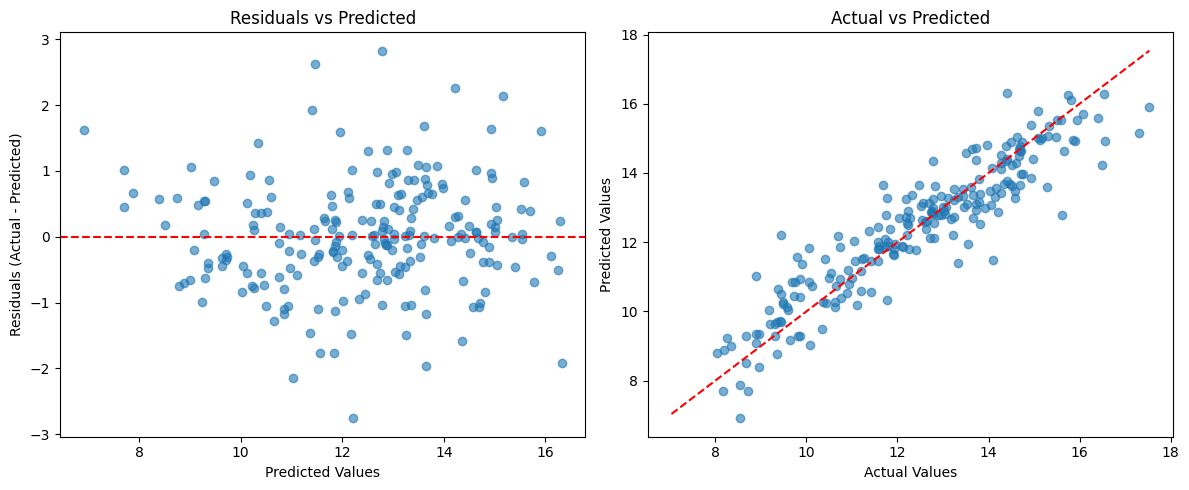

In [289]:
import matplotlib.pyplot as plt
import numpy as np

# Residuals
residuals = y_test - y_pred_BIC

# Create side-by-side subplots
plt.figure(figsize=(12,5))

# --- Plot 1: Residuals vs Predicted ---
plt.subplot(1,2,1)
plt.scatter(y_pred_BIC, residuals, alpha=0.6)
plt.axhline(0, linestyle="--", color="Red")  # horizontal line at 0

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predicted")

# --- Plot 2: Actual vs Predicted ---
plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_BIC, alpha=0.6)

# 45-degree reference line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="Red")


plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.tight_layout()
plt.show()

### CLEAN MODEL NAMES ###

Sessions + Percentages (14 Features)

\begin{align}
\text{Hours} &= \beta_0 
+ \beta_1 (\text{Sessions}) 
+ \beta_2 (\%\text{Prostate})
+ \beta_3 (\%\text{Anesthesia}) 
+ \beta_4 (\%\text{Brain})
+ \beta_5 (\%\text{CSI})
+ \beta_6 (\%\text{HN}) \\

&\quad + \beta_7 (\%\text{Other})
+ \beta_8 (\%\text{Pediatric})
+ \beta_9 (\%\text{Spine})
+ \beta_{10} (\%\text{Thorax}) 
+ \beta_{11} (\%\text{Breast})
+ \beta_{12} (\%\text{CNS}) \\

&\quad + \beta_{13} (\%\text{Abdomen})
+ \beta_{14} (\%\text{Bone})
+ \varepsilon
\end{align}

\begin{align}
\text{Hours} &= 2.7044 
+ 0.3444 (\text{Sessions}) 
- 3.9799 (\%\text{Prostate})
+ 6.2460 (\%\text{Anesthesia}) 
- 1.5953 (\%\text{Brain})
+ 4.5752 (\%\text{CSI})
+ 2.5039 (\%\text{HN}) \\

&\quad + 13.1655 (\%\text{Other})
- 1.7210 (\%\text{Pediatric})
+ 0 (\%\text{Spine})
+ 3.4631 (\%\text{Thorax}) 
+ 4.9270 (\%\text{Breast})
+ 1.3299 (\%\text{CNS}) \\

&\quad + 1.8910 (\%\text{Abdomen})
+ 3.0696 (\%\text{Bone})
+ \varepsilon
\end{align}

Sessions + Percentages (8 Features)

\begin{align}
\text{Hours} &= \beta_0 
+ \beta_1 (\text{Sessions}) 
+ \beta_2 (\%\text{Prostate})
+ \beta_3 (\%\text{Anesthesia}) 
+ \beta_4 (\%\text{Brain})
+ \beta_5 (\%\text{CSI})
+ \beta_6 (\%\text{HN}) \\

&\quad + \beta_7 (\%\text{Other})
+ \beta_8 (\%\text{Pediatric})
+ \varepsilon
\end{align}

\begin{align}
\text{Hours} &= 3.9328 
+ 0.3444 (\text{Sessions}) 
- 5.2342 (\%\text{Prostate})
+ 6.2910 (\%\text{Anesthesia}) 
- 2.7901 (\%\text{Brain})
+ 5.0968 (\%\text{CSI})
+ 1.1613 (\%\text{HN}) \\

&\quad + 12.6830 (\%\text{Other})
- 1.6468 (\%\text{Pediatric})
+ \varepsilon
\end{align}

Cancer Types - No Sessions (13 Predictors)

\begin{align}
\text{Hours} &= \beta_0 
+ \beta_1 (\text{Prostate}) 
+ \beta_2 (\text{HN})
+ \beta_3 (\text{Pediatric}) 
+ \beta_4 (\text{CNS})
+ \beta_5 (\text{Brain})
+ \beta_6 (\text{Pelvis}) 
+ \beta_8 (\text{Thorax}) \\

&\quad + \beta_7 (\text{Anesthesia})
+ \beta_9 (\text{Abdomen})
+ \beta_{10} (\text{Bone}) 
+ \beta_{11} (\text{Other})
+ \beta_{12} (\text{CSI}) 
+ \beta_{13} (\text{Breast})
+ \varepsilon
\end{align}

\begin{align}
\text{Hours} &= 2.9999 
+ 0.1912 (\text{Prostate}) 
+ 0.4556 (\text{HN}) 
- 0.0689 (\text{Pediatric}) 
+ 0.4073 (\text{CNS}) 
+ 0.2772 (\text{Brain}) \\

&\quad + 0.2180 (\text{Anesthesia})
+ 0.3903 (\text{Pelvis})
+ 0.5105 (\text{Abdomen})
+ 0.4271 (\text{Thorax})
+ 0.4886 (\text{Bone})
+ \varepsilon
\end{align}